# Cane Corso Standard Check — тестова проба

Тук сравняваме примерни Cane Corso данни със стандарта.

Ще проверяваме:

- пол
- височина при холката
- тегло
- дали кучето е под, в или над стандартния диапазон

Това е учебна проба , не официална оценка.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
standard = pd.DataFrame({
    "Пол": ["мъжко", "женско"],
    "Минимална височина см": [64, 60],
    "Максимална височина см": [68, 64],
    "Минимално тегло кг": [45, 40],
    "Максимално тегло кг": [50, 45],
    "Толеранс височина см": [2, 2]
})

standard

,Пол,Минимална височина см,Максимална височина см,Минимално тегло кг,Максимално тегло кг,Толеранс височина см
0,мъжко,64,68,45,50,2
1,женско,60,64,40,45,2


In [2]:
dogs = pd.DataFrame({
    "Име": ["Маркус", "Брутос", "Хера", "Арес", "Белла"],
    "Пол": ["мъжко", "мъжко", "женско", "мъжко", "женско"],
    "Височина см": [66, 72, 62, 63, 58],
    "Тегло кг": [48, 56, 42, 43, 37]
})

dogs

,Име,Пол,Височина см,Тегло кг
0,Маркус,мъжко,66,48
1,Брутос,мъжко,72,56
2,Хера,женско,62,42
3,Арес,мъжко,63,43
4,Белла,женско,58,37


In [3]:
def check_standard(row):
    sex = row["Пол"]
    height = row["Височина см"]
    weight = row["Тегло кг"]

    standard_row = standard[standard["Пол"] == sex].iloc[0]

    min_height = standard_row["Минимална височина см"]
    max_height = standard_row["Максимална височина см"]
    min_weight = standard_row["Минимално тегло кг"]
    max_weight = standard_row["Максимално тегло кг"]
    tolerance = standard_row["Толеранс височина см"]

    allowed_min_height = min_height - tolerance
    allowed_max_height = max_height + tolerance

    if height < allowed_min_height:
        height_status = "под стандарта"
    elif height > allowed_max_height:
        height_status = "над стандарта"
    elif min_height <= height <= max_height:
        height_status = "в стандарта"
    else:
        height_status = "в толеранса"

    if weight < min_weight:
        weight_status = "под стандарта"
    elif weight > max_weight:
        weight_status = "над стандарта"
    else:
        weight_status = "в стандарта"

    return pd.Series({
        "Статус височина": height_status,
        "Статус тегло": weight_status
    })

In [4]:
results = dogs.copy()

results[["Статус височина", "Статус тегло"]] = dogs.apply(check_standard, axis=1)

results

,Име,Пол,Височина см,Тегло кг,Статус височина,Статус тегло
0,Маркус,мъжко,66,48,в стандарта,в стандарта
1,Брутос,мъжко,72,56,над стандарта,над стандарта
2,Хера,женско,62,42,в стандарта,в стандарта
3,Арес,мъжко,63,43,в толеранса,под стандарта
4,Белла,женско,58,37,в толеранса,под стандарта


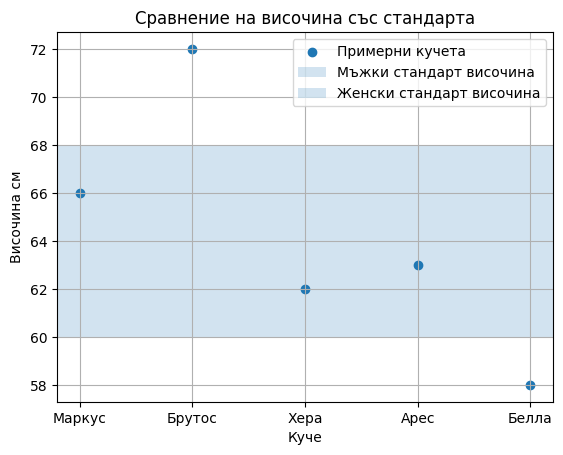

In [5]:
plt.scatter(dogs["Име"], dogs["Височина см"], label="Примерни кучета")

for _, row in standard.iterrows():
    if row["Пол"] == "мъжко":
        plt.axhspan(
            row["Минимална височина см"],
            row["Максимална височина см"],
            alpha=0.2,
            label="Мъжки стандарт височина"
        )
    else:
        plt.axhspan(
            row["Минимална височина см"],
            row["Максимална височина см"],
            alpha=0.2,
            label="Женски стандарт височина"
        )

plt.title("Сравнение на височина със стандарта")
plt.xlabel("Куче")
plt.ylabel("Височина см")
plt.grid(True)
plt.legend()
plt.show()

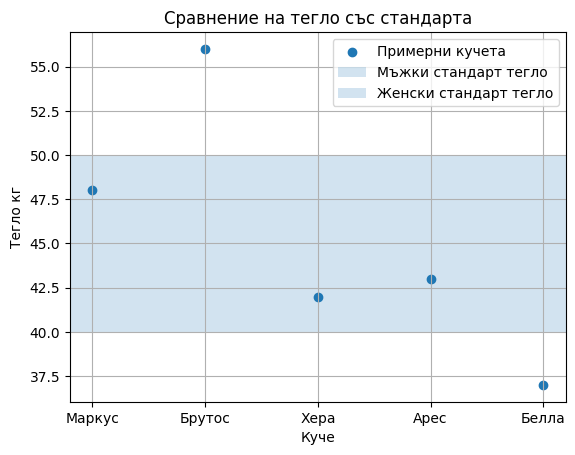

In [6]:
plt.scatter(dogs["Име"], dogs["Тегло кг"], label="Примерни кучета")

for _, row in standard.iterrows():
    if row["Пол"] == "мъжко":
        plt.axhspan(
            row["Минимално тегло кг"],
            row["Максимално тегло кг"],
            alpha=0.2,
            label="Мъжки стандарт тегло"
        )
    else:
        plt.axhspan(
            row["Минимално тегло кг"],
            row["Максимално тегло кг"],
            alpha=0.2,
            label="Женски стандарт тегло"
        )

plt.title("Сравнение на тегло със стандарта")
plt.xlabel("Куче")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
assert len(results) == len(dogs)
assert "Статус височина" in results.columns
assert "Статус тегло" in results.columns

print("Tests passed")

Tests passed


## 4. Регресия за растеж

Сега добавяме примерни данни за растеж по месеци.

- мъжко Cane Corso
- женско Cane Corso

Ще прогнозираме:

- тегло по месеци
- височина по месеци

 Данните са примерни.

In [8]:
import numpy as np

In [9]:
growth_data = pd.DataFrame({
    "Месец": [3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
              3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    
    "Пол": ["мъжко"] * 10 + ["женско"] * 10,
    
    "Тегло кг": [
        14, 19, 24, 29, 34, 39, 43, 46, 48, 50,
        12, 16, 21, 25, 30, 34, 38, 41, 43, 45
    ],
    
    "Височина см": [
        46, 53, 58, 62, 65, 66, 67, 68, 68, 68,
        44, 50, 55, 58, 60, 62, 63, 64, 64, 64
    ]
})

growth_data

,Месец,Пол,Тегло кг,Височина см
0,3,мъжко,14,46
1,4,мъжко,19,53
2,5,мъжко,24,58
3,6,мъжко,29,62
4,7,мъжко,34,65
5,8,мъжко,39,66
6,9,мъжко,43,67
7,10,мъжко,46,68
8,11,мъжко,48,68
9,12,мъжко,50,68


In [11]:
male_data = growth_data[growth_data["Пол"] == "мъжко"]
female_data = growth_data[growth_data["Пол"] == "женско"]

# Регресия за тегло
male_weight_a, male_weight_b = np.polyfit(male_data["Месец"], male_data["Тегло кг"], 1)
female_weight_a, female_weight_b = np.polyfit(female_data["Месец"], female_data["Тегло кг"], 1)

# Регресия за височина
male_height_a, male_height_b = np.polyfit(male_data["Месец"], male_data["Височина см"], 1)
female_height_a, female_height_b = np.polyfit(female_data["Месец"], female_data["Височина см"], 1)

print("Мъжко тегло формула:")
print(f"тегло = {male_weight_a:.2f} * месец + {male_weight_b:.2f}")

print()

print("Женско тегло формула:")
print(f"тегло = {female_weight_a:.2f} * месец + {female_weight_b:.2f}")

print()

print("Мъжко височина формула:")
print(f"височина = {male_height_a:.2f} * месец + {male_height_b:.2f}")

print()

print("Женско височина формула:")
print(f"височина = {female_height_a:.2f} * месец + {female_height_b:.2f}")

Мъжко тегло формула:
тегло = 4.15 * месец + 3.51

Женско тегло формула:
тегло = 3.81 * месец + 1.91

Мъжко височина формула:
височина = 2.24 * месец + 45.33

Женско височина формула:
височина = 2.06 * месец + 42.95


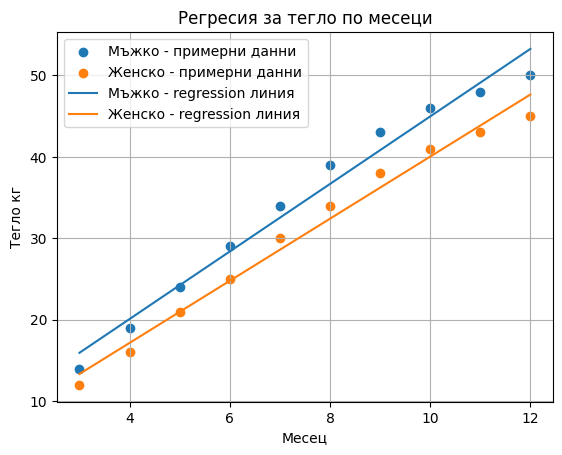

In [12]:
months = np.array(range(3, 13))

male_weight_prediction = male_weight_a * months + male_weight_b
female_weight_prediction = female_weight_a * months + female_weight_b

plt.scatter(male_data["Месец"], male_data["Тегло кг"], label="Мъжко - примерни данни")
plt.scatter(female_data["Месец"], female_data["Тегло кг"], label="Женско - примерни данни")

plt.plot(months, male_weight_prediction, label="Мъжко - regression линия")
plt.plot(months, female_weight_prediction, label="Женско - regression линия")

plt.title("Регресия за тегло по месеци")
plt.xlabel("Месец")
plt.ylabel("Тегло кг")
plt.grid(True)
plt.legend()

plt.show()

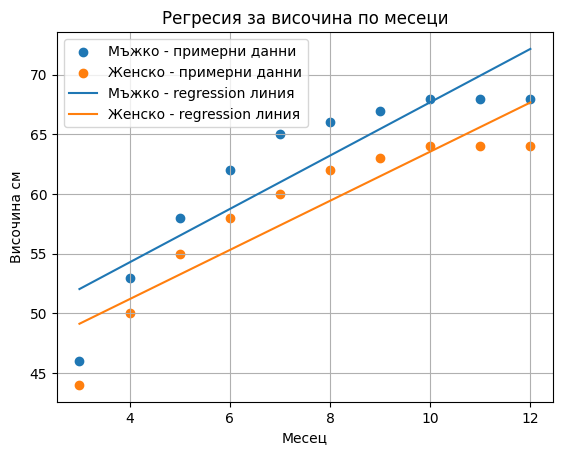

In [13]:
male_height_prediction = male_height_a * months + male_height_b
female_height_prediction = female_height_a * months + female_height_b

plt.scatter(male_data["Месец"], male_data["Височина см"], label="Мъжко - примерни данни")
plt.scatter(female_data["Месец"], female_data["Височина см"], label="Женско - примерни данни")

plt.plot(months, male_height_prediction, label="Мъжко - regression линия")
plt.plot(months, female_height_prediction, label="Женско - regression линия")

plt.title("Регресия за височина по месеци")
plt.xlabel("Месец")
plt.ylabel("Височина см")
plt.grid(True)
plt.legend()

plt.show()

In [14]:
пол = "мъжко"
месец = 8

if пол == "мъжко":
    predicted_weight = male_weight_a * месец + male_weight_b
    predicted_height = male_height_a * месец + male_height_b
else:
    predicted_weight = female_weight_a * месец + female_weight_b
    predicted_height = female_height_a * месец + female_height_b

print("Пол:", пол)
print("Месец:", месец)
print("Прогнозно тегло:", round(predicted_weight, 1), "кг")
print("Прогнозна височина:", round(predicted_height, 1), "см")

Пол: мъжко
Месец: 8
Прогнозно тегло: 36.7 кг
Прогнозна височина: 63.2 см


In [15]:
пол = "мъжко"
месец = 8
реално_тегло = 47
реална_височина = 67

if пол == "мъжко":
    прогнозно_тегло = male_weight_a * месец + male_weight_b
    прогнозна_височина = male_height_a * месец + male_height_b
else:
    прогнозно_тегло = female_weight_a * месец + female_weight_b
    прогнозна_височина = female_height_a * месец + female_height_b

разлика_тегло = реално_тегло - прогнозно_тегло
разлика_височина = реална_височина - прогнозна_височина

print("Пол:", пол)
print("Месец:", месец)

print()
print("Реално тегло:", реално_тегло, "кг")
print("Прогнозно тегло:", round(прогнозно_тегло, 1), "кг")
print("Разлика:", round(разлика_тегло, 1), "кг")

print()
print("Реална височина:", реална_височина, "см")
print("Прогнозна височина:", round(прогнозна_височина, 1), "см")
print("Разлика:", round(разлика_височина, 1), "см")

Пол: мъжко
Месец: 8

Реално тегло: 47 кг
Прогнозно тегло: 36.7 кг
Разлика: 10.3 кг

Реална височина: 67 см
Прогнозна височина: 63.2 см
Разлика: 3.8 см


In [16]:
def mse(real, predicted):
    return np.mean((real - predicted) ** 2)

male_weight_mse = mse(male_data["Тегло кг"], male_weight_a * male_data["Месец"] + male_weight_b)
female_weight_mse = mse(female_data["Тегло кг"], female_weight_a * female_data["Месец"] + female_weight_b)

male_height_mse = mse(male_data["Височина см"], male_height_a * male_data["Месец"] + male_height_b)
female_height_mse = mse(female_data["Височина см"], female_height_a * female_data["Месец"] + female_height_b)

mse_table = pd.DataFrame({
    "Модел": [
        "Мъжко тегло",
        "Женско тегло",
        "Мъжко височина",
        "Женско височина"
    ],
    "MSE": [
        male_weight_mse,
        female_weight_mse,
        male_height_mse,
        female_height_mse
    ]
})

mse_table

,Модел,MSE
0,Мъжко тегло,3.065455
1,Женско тегло,1.958788
2,Мъжко височина,9.829091
3,Женско височина,7.009697


In [17]:
assert male_weight_a > 0
assert female_weight_a > 0
assert male_height_a > 0
assert female_height_a > 0

print("Tests passed")

Tests passed


# Обобщение

В тази тестова проба направихме beginner-friendly анализ за Cane Corso .

Първо въведохме примерен стандарт за възрастно Cane Corso според пол:

- мъжко куче
- женско куче
- височина при холката
- тегло
- допустим толеранс за височина

След това създадохме примерни кучета и сравнихме техните данни със стандарта.

Проверявахме дали всяко куче е:

- под стандарта
- в стандарта
- в толеранса
- над стандарта

---

## Какво добавихме след това?

Добавихме примерни данни за растеж по месеци.

Създадохме отделни данни за:

- мъжко Cane Corso
- женско Cane Corso

След това направихме regression модели за:

- тегло при мъжко куче
- тегло при женско куче
- височина при мъжко куче
- височина при женско куче

---

## Какво прави регресията?

Регресията намира линия на тенденция.

Тя ни помага да видим как приблизително се променят теглото и височината с времето.

Пример:

- ако кучето е на 8 месеца, можем да прогнозираме очаквано тегло
- ако кучето е на 8 месеца, можем да прогнозираме очаквана височина
- после можем да сравним реалните данни с прогнозата

---

## За какво може да се използва това?

Тази логика може да се използва като помощен инструмент за:

1. сравнение със стандарта
2. проследяване на растежа
3. прогнозиране на тегло и височина по месеци
4. отделна проверка за мъжко и женско куче
5. откриване на стойности, които са много над или под очакваното
6. бъдещ Growth Tracker в Cane Corso платформа

---

## Важно уточнение


Регресията показва:

- каква е тенденцията според въведените данни
- каква стойност се очаква приблизително
- дали конкретното куче е под, около или над прогнозата

---

## Финална идея

Комбинираме две неща:

1. **Стандарт** — използва се за възрастно Cane Corso.
2. **Регресия** — използва се за растеж и прогнозиране по месеци.

Така получаваме прост, разбираем и полезен анализ:

стандарт → примерни кучета → сравнение → растеж → регресия → прогноза → MSE → tests